# Online Retail Sales Performance & Customer Analytics

## Task 3: Dataset Selection & Data Preparation

**Dataset:** Online Retail  
**Source:** UCI Machine Learning Repository  
**Period:** December 2010 – December 2011  
**Tools:** Python, Pandas, NumPy, Matplotlib

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
file_path = "../data/Online Retail.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset loaded successfully!
Number of rows: 541909
Number of columns: 8


In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


In [5]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

In [6]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

print("Missing values by column:")
print(missing_values)

Missing values by column:
Description      1454
CustomerID     135080
dtype: int64


In [7]:
missing_percentage = (df.isnull().sum() / len(df) * 100).round(2)

missing_percentage = missing_percentage[missing_percentage > 0]

print("Missing value percentage:")
print(missing_percentage)

Missing value percentage:
Description     0.27
CustomerID     24.93
dtype: float64


In [8]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 5268


In [9]:
duplicate_percentage = (duplicate_count / len(df) * 100).round(2)

print("Percentage of duplicate rows:", duplicate_percentage, "%")

Percentage of duplicate rows: 0.97 %


In [10]:
# Identify cancelled invoices
cancelled = df[df["InvoiceNo"].astype(str).str.startswith("C")]

print("Number of cancelled invoice rows:", len(cancelled))
print("Total cancelled quantity:", abs(cancelled["Quantity"].sum()))

Number of cancelled invoice rows: 9288
Total cancelled quantity: 277574


In [11]:
# Check negative quantities
negative_quantity = df[df["Quantity"] < 0]

print("Rows with negative quantity:", len(negative_quantity))
print("Minimum quantity:", df["Quantity"].min())

Rows with negative quantity: 10624
Minimum quantity: -80995


In [12]:
# Check negative unit prices
negative_price = df[df["UnitPrice"] < 0]

print("Rows with negative unit price:", len(negative_price))
print("Minimum unit price:", df["UnitPrice"].min())

Rows with negative unit price: 2
Minimum unit price: -11062.06


In [13]:
# Create a copy of the original dataset
clean_df = df.copy()

# 1. Remove duplicate records
clean_df = clean_df.drop_duplicates()

# 2. Remove rows with missing product descriptions
clean_df = clean_df.dropna(subset=["Description"])

# 3. Remove cancelled invoices
clean_df = clean_df[
    ~clean_df["InvoiceNo"].astype(str).str.startswith("C")
]

# 4. Remove transactions with zero or negative quantity
clean_df = clean_df[clean_df["Quantity"] > 0]

# 5. Remove transactions with zero or negative unit price
clean_df = clean_df[clean_df["UnitPrice"] > 0]

# 6. Calculate sales amount
clean_df["SalesAmount"] = clean_df["Quantity"] * clean_df["UnitPrice"]

print("Original rows:", len(df))
print("Cleaned rows:", len(clean_df))
print("Rows removed:", len(df) - len(clean_df))

Original rows: 541909
Cleaned rows: 524878
Rows removed: 17031


In [14]:
print("Missing Description:", clean_df["Description"].isnull().sum())
print("Duplicate rows:", clean_df.duplicated().sum())
print("Negative Quantity:", (clean_df["Quantity"] < 0).sum())
print("Negative Unit Price:", (clean_df["UnitPrice"] < 0).sum())
print("Total Sales Amount: £", round(clean_df["SalesAmount"].sum(), 2))

Missing Description: 0
Duplicate rows: 0
Negative Quantity: 0
Negative Unit Price: 0
Total Sales Amount: £ 10642110.8


In [15]:
clean_file_path = "../data/online_retail_cleaned.xlsx"

clean_df.to_excel(clean_file_path, index=False)

print("Cleaned dataset saved successfully!")
print("File:", clean_file_path)

Cleaned dataset saved successfully!
File: ../data/online_retail_cleaned.xlsx


In [16]:
print("Cleaned dataset shape:", clean_df.shape)
print("Date range:", clean_df["InvoiceDate"].min(), "to", clean_df["InvoiceDate"].max())
print("Number of countries:", clean_df["Country"].nunique())
print("Number of unique products:", clean_df["StockCode"].nunique())

Cleaned dataset shape: (524878, 9)
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Number of countries: 38
Number of unique products: 3922


In [17]:
# Task 4: Descriptive Statistics

clean_df[["Quantity", "UnitPrice", "SalesAmount"]].describe()

,Quantity,UnitPrice,SalesAmount
count,524878.000000,524878.000000,524878.000000
mean,10.616600,3.922573,20.275399
std,156.280031,36.093028,271.693566
min,1.000000,0.001000,0.001000
25%,1.000000,1.250000,3.900000
50%,4.000000,2.080000,9.920000
75%,11.000000,4.130000,17.700000
max,80995.000000,13541.330000,168469.600000


In [18]:
# Correlation Analysis

correlation = clean_df[["Quantity", "UnitPrice", "SalesAmount"]].corr()

print("Correlation Matrix:")
print(correlation.round(2))

Correlation Matrix:
             Quantity  UnitPrice  SalesAmount
Quantity         1.00      -0.00         0.91
UnitPrice       -0.00       1.00         0.14
SalesAmount      0.91       0.14         1.00


In [19]:
# Outlier Identification using IQR method

def find_outliers(column):
    Q1 = clean_df[column].quantile(0.25)
    Q3 = clean_df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    outliers = clean_df[
        (clean_df[column] < lower_limit) |
        (clean_df[column] > upper_limit)
    ]
    
    return len(outliers), lower_limit, upper_limit

for column in ["Quantity", "UnitPrice", "SalesAmount"]:
    count, lower, upper = find_outliers(column)
    print(column)
    print("Number of outliers:", count)
    print("Lower limit:", round(lower, 2))
    print("Upper limit:", round(upper, 2))
    print()

Quantity
Number of outliers: 27111
Lower limit: -14.0
Upper limit: 26.0

UnitPrice
Number of outliers: 37827
Lower limit: -3.07
Upper limit: 8.45

SalesAmount
Number of outliers: 42624
Lower limit: -16.8
Upper limit: 38.4



In [20]:
# Monthly Sales Trend

clean_df["YearMonth"] = clean_df["InvoiceDate"].dt.to_period("M")

monthly_sales = clean_df.groupby("YearMonth")["SalesAmount"].sum()

print("Monthly Sales:")
print(monthly_sales)

Monthly Sales:
YearMonth
2010-12     821452.730
2011-01     689811.610
2011-02     522545.560
2011-03     716215.260
2011-04     536968.491
2011-05     769296.610
2011-06     760547.010
2011-07     718076.121
2011-08     757841.380
2011-09    1056435.192
2011-10    1151263.730
2011-11    1503866.780
2011-12     637790.330
Freq: M, Name: SalesAmount, dtype: float64


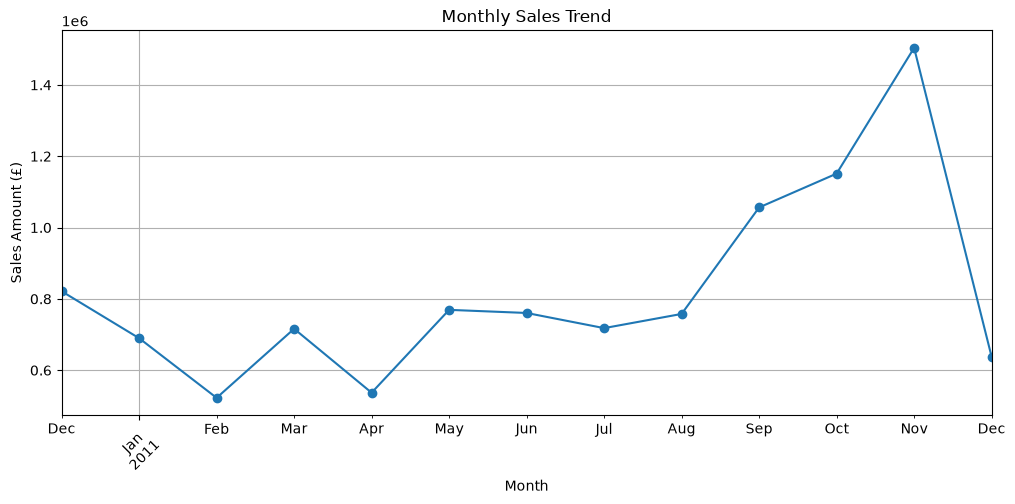

In [21]:
# Plot monthly sales trend

plt.figure(figsize=(12, 5))

monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales Amount (£)")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [22]:
# Highest and Lowest Sales Months

highest_month = monthly_sales.idxmax()
lowest_month = monthly_sales.idxmin()

print("Highest sales month:", highest_month)
print("Highest sales amount: £", round(monthly_sales.max(), 2))

print("Lowest sales month:", lowest_month)
print("Lowest sales amount: £", round(monthly_sales.min(), 2))

Highest sales month: 2011-11
Highest sales amount: £ 1503866.78
Lowest sales month: 2011-02
Lowest sales amount: £ 522545.56


## Task 4: EDA Findings

### Descriptive Statistics
The cleaned dataset contains 524,878 records. The average quantity per transaction is approximately 10.62 units, while the median quantity is 4 units. The average sales amount is approximately £20.28 and the median sales amount is £9.92. This indicates that most transactions are relatively small.

### Data Inspection and Cleaning
The original dataset contained 541,909 rows and 8 columns. Missing values were identified in the Description and CustomerID columns. Duplicate records and invalid negative quantities/unit prices were also identified during data cleaning. After cleaning, 524,878 valid rows remained.

### Missing-Value Handling
Missing values in the Description column were removed during the cleaning process. CustomerID contained a significant number of missing values and was not required for the main sales calculations.

### Correlation Analysis
Correlation analysis was performed on Quantity, UnitPrice and SalesAmount. The correlation matrix helps identify linear relationships between these numerical variables. Since SalesAmount is calculated from Quantity and UnitPrice, it is expected to have a relationship with these variables.

### Outlier Analysis
The IQR method was used to identify outliers in Quantity, UnitPrice and SalesAmount. The descriptive statistics show very large maximum values compared with the median values, indicating the presence of unusually large transactions.

### Patterns and Trends
Monthly sales show noticeable variation throughout the period. Sales were relatively low during February 2011, which recorded the lowest monthly sales of £522,545.56. Sales increased substantially during September, October and November, with November 2011 recording the highest monthly sales of £1,503,866.78. The sharp increase toward the end of the year indicates stronger sales activity during this period.
### Overall Finding
The EDA shows that the Online Retail dataset contains a large number of transactions with relatively small typical order values, along with a smaller number of unusually large transactions. Sales performance varies across time, and correlation analysis provides insight into the relationship between quantity, unit price and sales amount.

# Task 5: Data Visualization

The following visualizations are created to communicate important patterns, trends, comparisons, and relationships in the cleaned Online Retail dataset.

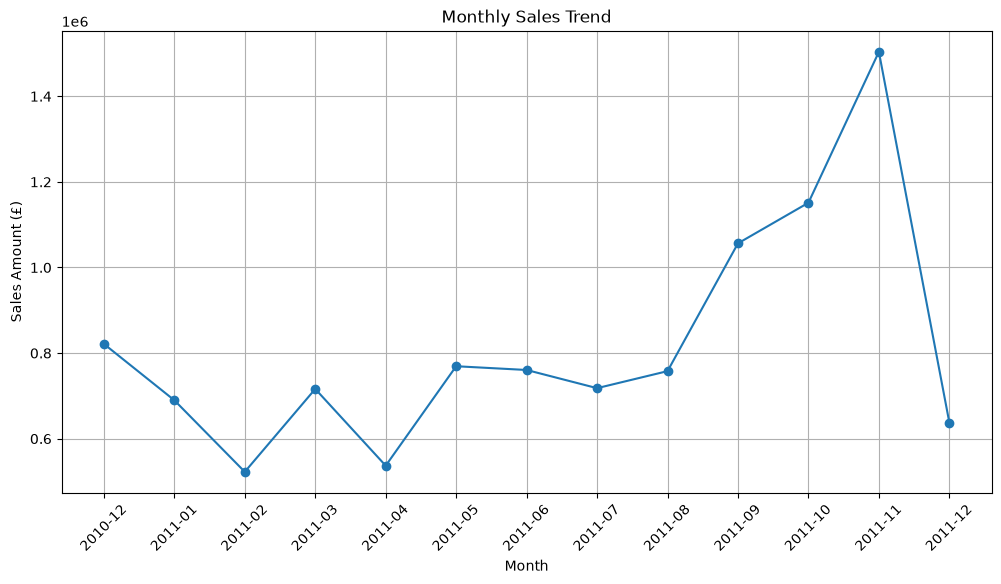

In [23]:
# Visualization 1: Monthly Sales Trend

monthly_sales = clean_df.groupby(
    clean_df["InvoiceDate"].dt.to_period("M")
)["SalesAmount"].sum()

plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales Amount (£)")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

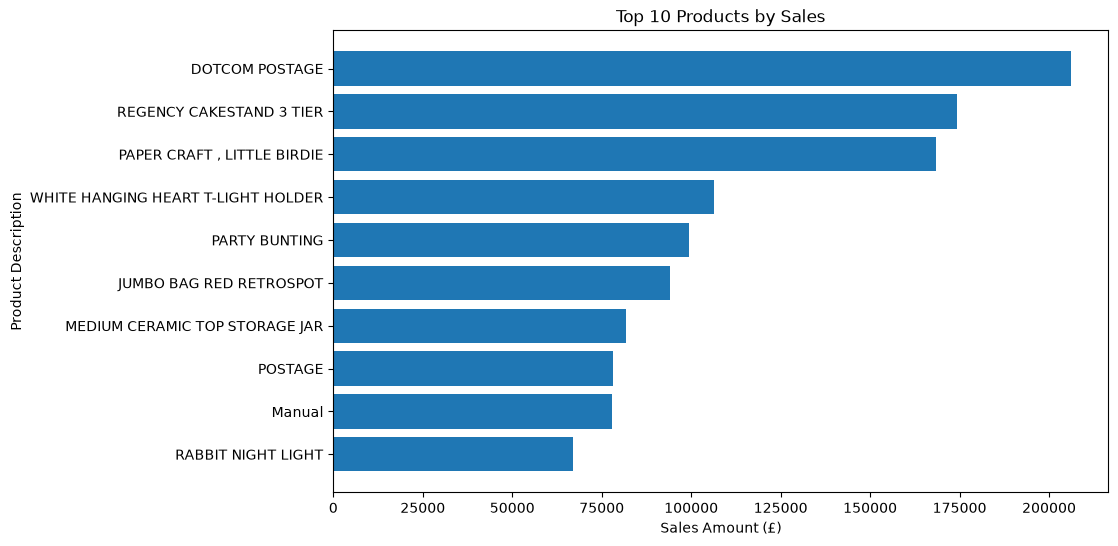

In [24]:
# Visualization 2: Top 10 Products by Sales

top_products = (
    clean_df.groupby("Description")["SalesAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.barh(top_products.index[::-1], top_products.values[::-1])

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales Amount (£)")
plt.ylabel("Product Description")

plt.show()

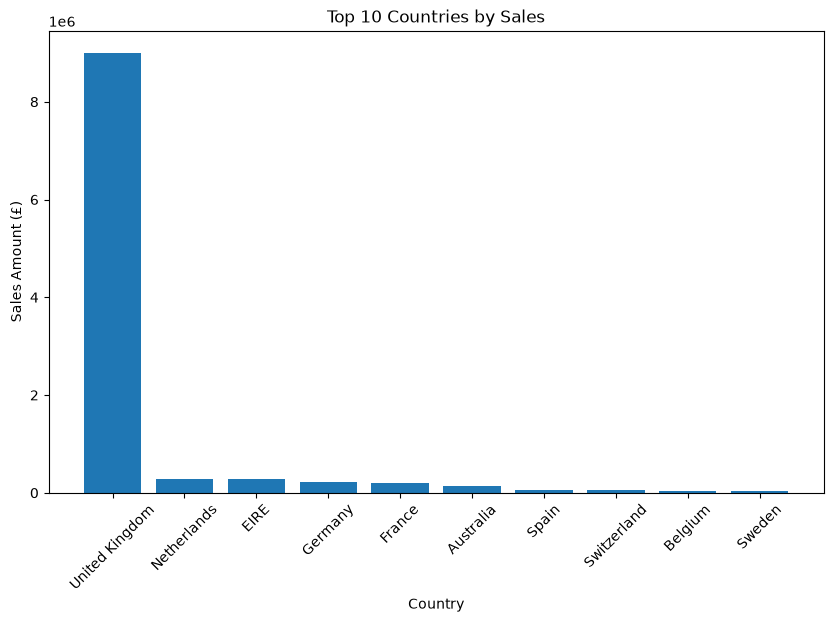

In [25]:
# Visualization 3: Top 10 Countries by Sales

top_countries = (
    clean_df.groupby("Country")["SalesAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.bar(top_countries.index, top_countries.values)

plt.title("Top 10 Countries by Sales")
plt.xlabel("Country")
plt.ylabel("Sales Amount (£)")
plt.xticks(rotation=45)

plt.show()

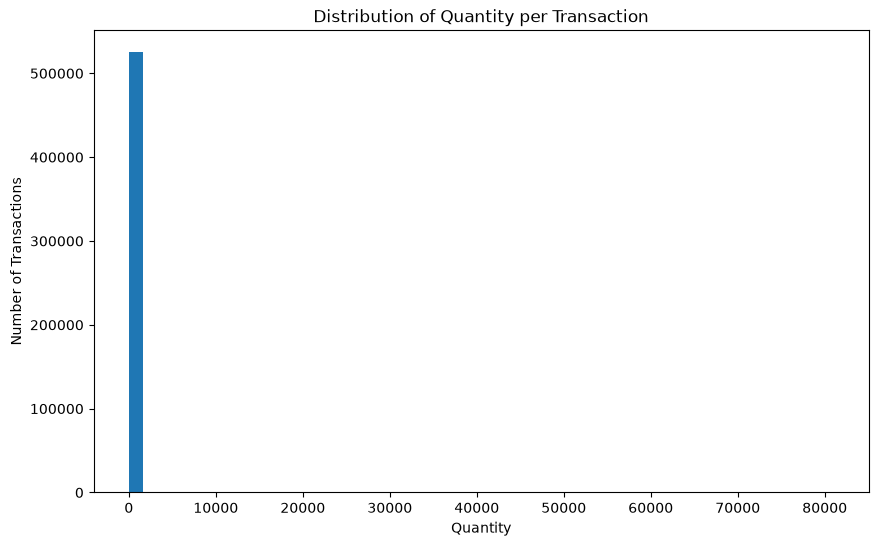

In [26]:
# Visualization 4: Distribution of Quantity

plt.figure(figsize=(10, 6))
plt.hist(clean_df["Quantity"], bins=50)

plt.title("Distribution of Quantity per Transaction")
plt.xlabel("Quantity")
plt.ylabel("Number of Transactions")

plt.show()

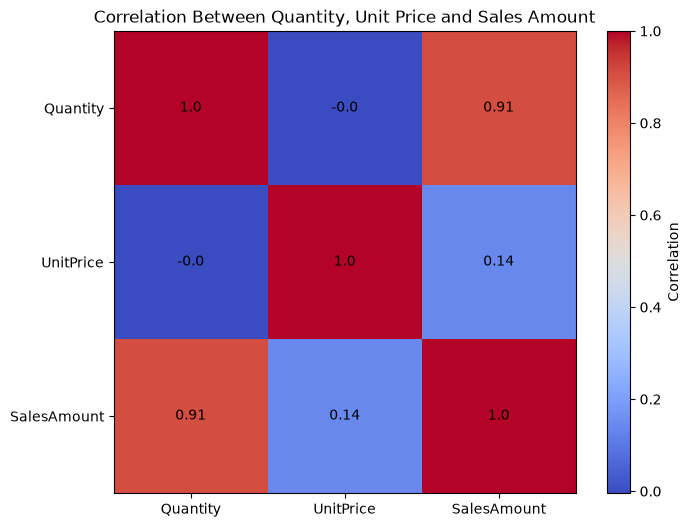

In [27]:
# Visualization 5: Correlation Heatmap

correlation = clean_df[["Quantity", "UnitPrice", "SalesAmount"]].corr()

plt.figure(figsize=(8, 6))
plt.imshow(correlation, cmap="coolwarm")

plt.colorbar(label="Correlation")

plt.xticks(range(len(correlation.columns)), correlation.columns)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Between Quantity, Unit Price and Sales Amount")

for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        plt.text(j, i, round(correlation.iloc[i, j], 2),
                 ha="center", va="center")

plt.show()

## Visualization Findings

The visualizations provide a clear understanding of the sales dataset. The monthly sales trend shows considerable variation in sales performance over time, with sales increasing significantly toward the end of 2011. The Top 10 Products chart identifies the products contributing the highest sales amounts, while the Top 10 Countries chart highlights the major markets. The quantity distribution shows that most transactions involve relatively small quantities, with a smaller number of unusually large transactions. The correlation heatmap shows the relationships between Quantity, UnitPrice and SalesAmount.

# Task 7: Business Insights & Recommendations

## Business Insights

### 1. Strong increase in sales toward the end of 2011

Monthly sales varied throughout the period, but sales increased substantially from September to November 2011. November 2011 recorded the highest monthly sales of £1,503,866.78, while February 2011 recorded the lowest at £522,545.56. This indicates stronger customer purchasing activity toward the end of the year.

### 2. The United Kingdom is the dominant market

The United Kingdom generated by far the highest sales compared with other countries. The Netherlands, EIRE, Germany and France were among the other important markets, but their sales were considerably lower than the UK.

### 3. A small group of products contributes significantly to sales

The Top 10 Products analysis shows that a limited number of products generate a significant portion of total sales. DOTCOM POSTAGE was the highest-performing item by sales, followed by products such as REGENCY CAKESTAND 3 TIER and PAPER CRAFT, LITTLE BIRDIE.

### 4. Most transactions involve relatively small quantities

The quantity distribution shows that most transactions contain relatively small quantities. However, there are a small number of unusually large transactions, creating significant outliers. This suggests that the business serves both regular retail buyers and customers placing very large orders.

### 5. Sales vary considerably by day of the week

The dashboard shows that sales are generally strongest on Tuesday and Thursday, while Sunday has substantially lower sales. This indicates that purchasing activity is concentrated on particular weekdays.

## Business Recommendations

### 1. Prepare inventory and marketing campaigns for high-sales periods

Since sales increase significantly during September–November, the company should prepare sufficient inventory and logistics capacity before this period. Targeted promotions and seasonal campaigns could also be launched before the high-sales months to maximize revenue.

### 2. Focus on high-performing products and key markets

The company should maintain sufficient stock of the highest-selling products and use them in promotions or product bundles. Since the UK is the dominant market, the business should continue strengthening its UK customer base while developing targeted marketing strategies for promising international markets such as the Netherlands, EIRE, Germany and France.

## Overall Conclusion

The analysis shows that Online Retail sales are concentrated around specific periods, products and markets. Sales increased strongly toward the end of 2011, the United Kingdom was the dominant market, and a small number of products contributed substantially to revenue. These findings can help the business improve inventory planning, marketing campaigns, product management and market expansion strategies.